#Air Quality Prediction using Multiple Linear Regression

##Project Overview

Air quality and atmospheric conditions are closely influenced by pollutant concentrations and environmental factors. Understanding these relationships is important for environmental monitoring, weather analysis, and public health management.

**In this project, a Multiple Linear Regression model is developed to predict Absolute Humidity (AH) using air quality sensor measurements and meteorological variables. The dataset contains readings collected from air quality monitoring stations, including concentrations of pollutants such as carbon monoxide (CO), nitrogen oxides (NOx), benzene (C6H6), and several sensor-based measurements, along with temperature and relative humidity.**

####The objective is to analyze how these variables collectively influence atmospheric humidity and to build a predictive model capable of estimating Absolute Humidity accurately.

### **Features in the Dataset**:

- **ID**: Unique identifier for each record  
- **Date**: Date of data capture  
- **Time**: Time of data capture  
- **CO(GT)**: Concentration of carbon monoxide in mg/m³  
- **PT08.S1(CO)**: Sensor 1 reading (tin oxide)  
- **NMHC(GT)**: Non-methane hydrocarbons in µg/m³  
- **C6H6(GT)**: Benzene concentration in µg/m³  
- **PT08.S2(NMHC)**: Sensor 2 reading (titania)  
- **NOx(GT)**: Concentration of NOx in µg/m³  
- **PT08.S3(NOx)**: Sensor 3 reading (tungsten oxide)  
- **NO2(GT)**: Concentration of NO2 in µg/m³  
- **PT08.S4(NO2)**: Sensor 4 reading (indium oxide)  
- **PT08.S5(O3)**: Sensor 5 reading (semiconductor)  
- **T**: Temperature in °C  
- **RH**: Relative Humidity in %  

### **Target Variable**:
- **AH**: Absolute Humidity (g/m³) — this is the continuous variable we aim to predict.

#Project Workflow

1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Missing Value Investigation
4. Correlation Analysis
5. Feature Selection
6. Multiple Linear Regression Model Training
7. Model Evaluation using R², MAE, and RMSE
8. Prediction Generation
9. Result Analysis and Conclusion

Expected Outcome

The final model should learn the relationship between pollutant measurements, environmental conditions, and atmospheric humidity, enabling accurate prediction of Absolute Humidity for unseen observations.

##Import Libraries

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

##Load Dataset

In [9]:
url1 = 'https://new-assets.ccbp.in/frontend/content/aiml/classical-ml/air_quality_train_data.csv'
url2 = 'https://new-assets.ccbp.in/frontend/content/aiml/classical-ml/air_quality_test_data.csv'

train_data = pd.read_csv(url1)
test_data = pd.read_csv(url2)

In [10]:
train_data.shape

(7485, 16)

In [11]:
train_data.head()

,ID,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,4367,08/09/2004,17.00.00,3.4,-200.0,-200.0,-200.0,-200.0,-200.0,-200.0,-200.0,-200.0,-200.0,-200.0,-200.0,-200.0000
1,794,12/04/2004,20.00.00,1.2,964.0,68.0,3.7,692.0,88.0,1176.0,82.0,1292.0,573.0,10.6,57.7,0.7362
2,8496,27/02/2005,18.00.00,1.2,905.0,-200.0,2.9,648.0,188.0,1007.0,132.0,822.0,509.0,6.8,41.0,0.4072
3,3027,14/07/2004,21.00.00,2.9,1084.0,-200.0,16.7,1200.0,185.0,686.0,159.0,1753.0,1505.0,27.8,26.6,0.9748
4,8508,28/02/2005,06.00.00,0.3,779.0,-200.0,0.2,402.0,34.0,1665.0,31.0,684.0,257.0,2.8,52.6,0.3972


##Dataset Information

In [3]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7485 entries, 0 to 7484
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             7485 non-null   int64  
 1   Date           7485 non-null   object 
 2   Time           7485 non-null   object 
 3   CO(GT)         7485 non-null   float64
 4   PT08.S1(CO)    7485 non-null   float64
 5   NMHC(GT)       7485 non-null   float64
 6   C6H6(GT)       7485 non-null   float64
 7   PT08.S2(NMHC)  7485 non-null   float64
 8   NOx(GT)        7485 non-null   float64
 9   PT08.S3(NOx)   7485 non-null   float64
 10  NO2(GT)        7485 non-null   float64
 11  PT08.S4(NO2)   7485 non-null   float64
 12  PT08.S5(O3)    7485 non-null   float64
 13  T              7485 non-null   float64
 14  RH             7485 non-null   float64
 15  AH             7485 non-null   float64
dtypes: float64(13), int64(1), object(2)
memory usage: 935.8+ KB


##Statistical Summary

In [4]:
train_data.describe()

,ID,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7485.000000,7485.000000,7485.000000,7485.000000,7485.000000,7485.000000,7485.000000,7485.000000,7485.000000,7485.000000,7485.000000,7485.000000,7485.000000,7485.000000
mean,4685.410421,-34.444823,1048.788911,-160.067201,1.825037,894.179826,168.168203,795.226720,57.395591,1390.735337,975.121176,9.692692,39.592091,-6.870408
std,2699.692736,77.852423,329.930322,137.601517,41.455288,342.468806,258.612341,323.158037,127.614479,466.822203,456.818858,43.272421,51.335843,39.055223
min,1.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,2343.000000,0.600000,922.000000,-200.000000,4.000000,709.000000,49.000000,639.000000,53.000000,1185.000000,701.000000,11.000000,34.400000,0.690700
50%,4709.000000,1.500000,1053.000000,-200.000000,7.900000,895.000000,140.000000,794.000000,96.000000,1445.000000,942.000000,17.100000,48.700000,0.980100
75%,7024.000000,2.600000,1222.000000,-200.000000,13.600000,1105.000000,282.000000,961.000000,133.000000,1662.000000,1254.000000,23.900000,62.000000,1.297300
max,9356.000000,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1389.000000,2683.000000,340.000000,2691.000000,2522.000000,44.600000,88.700000,2.231000


##Missing Value Analysis

In [5]:
missing_counts = (train_data == -200).sum()

missing_counts.sort_values(ascending=False)

,0
NMHC(GT),6769
CO(GT),1355
NO2(GT),1332
NOx(GT),1330
PT08.S2(NMHC),294
PT08.S3(NOx),294
PT08.S1(CO),294
C6H6(GT),294
PT08.S5(O3),294
T,294


#Missing Values Visualization

###Target Variable Distribution

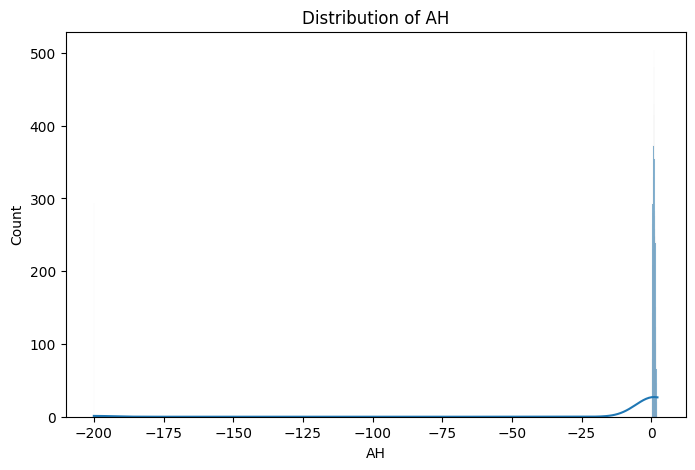

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_data['AH'],
    kde=True
)

plt.title("Distribution of AH")
plt.show()

##Numerical Features Distribution

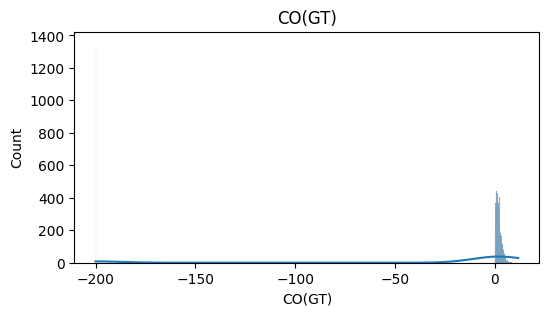

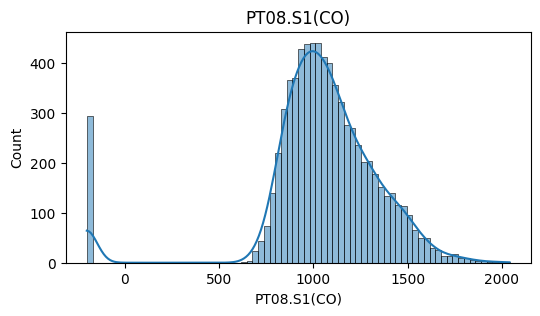

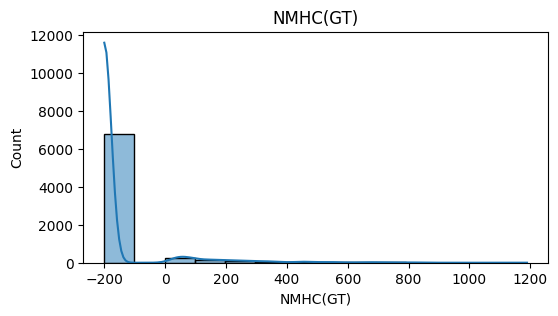

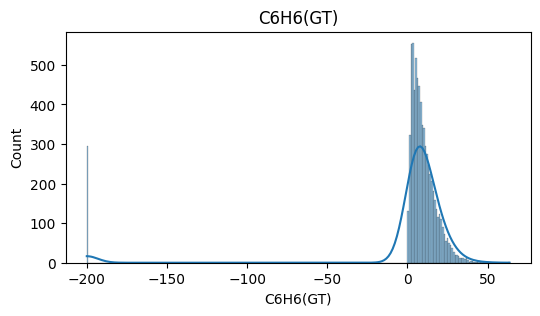

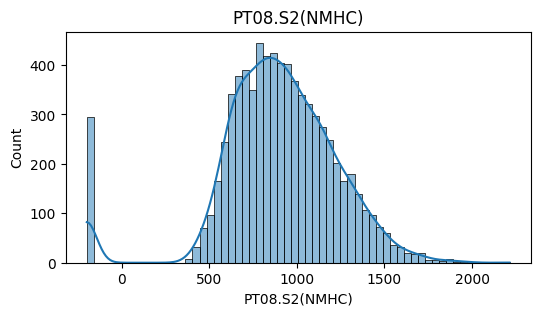

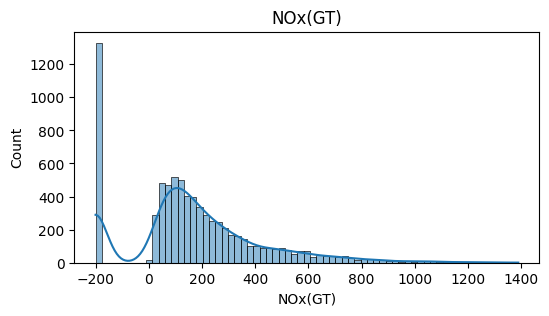

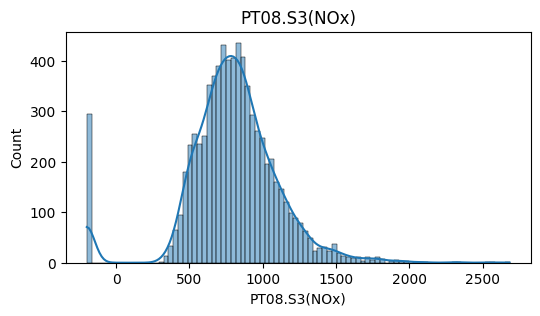

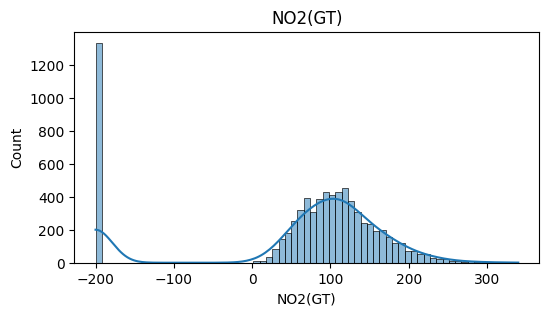

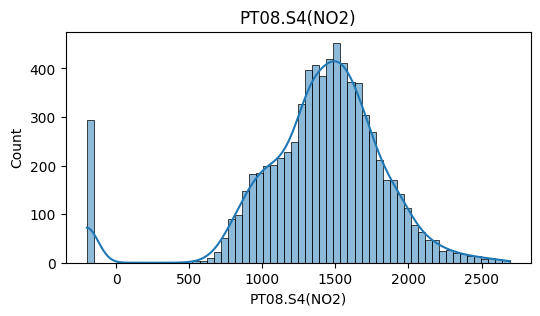

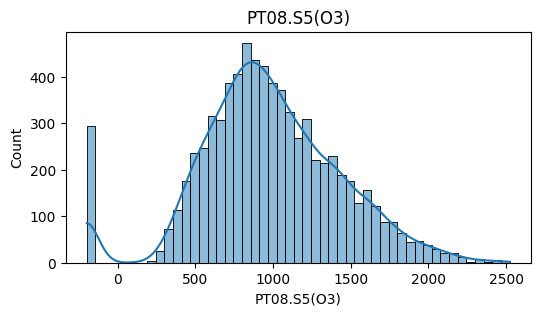

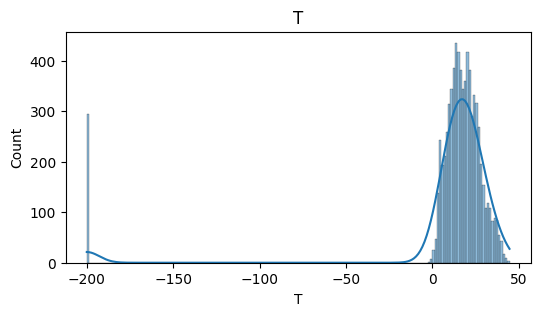

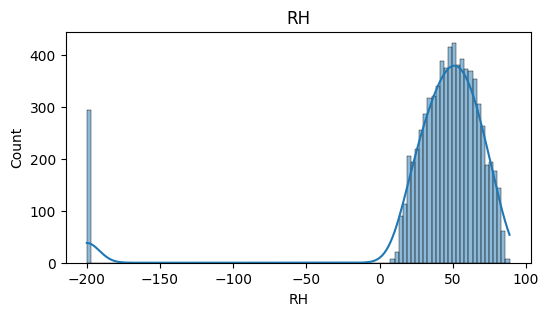

In [13]:
for col in train_data.columns[3:-1]:

    plt.figure(figsize=(6,3))

    sns.histplot(
        train_data[col],
        kde=True
    )

    plt.title(col)

    plt.show()

##Outlier Analysis

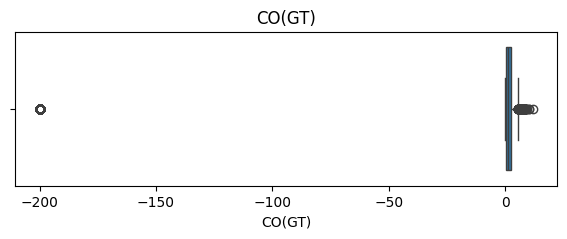

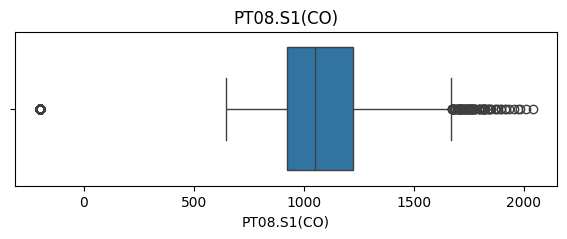

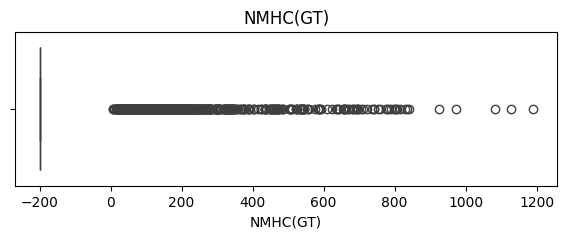

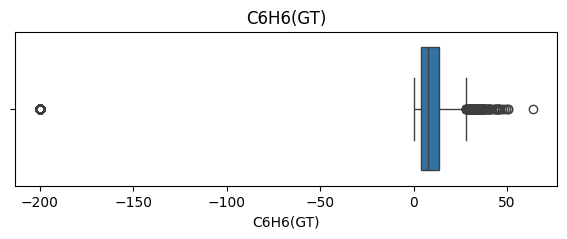

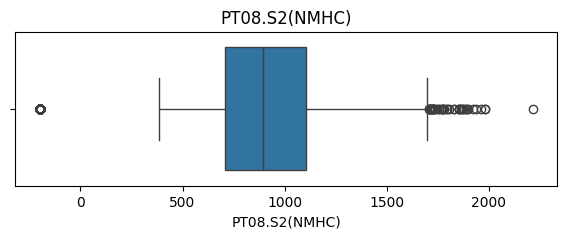

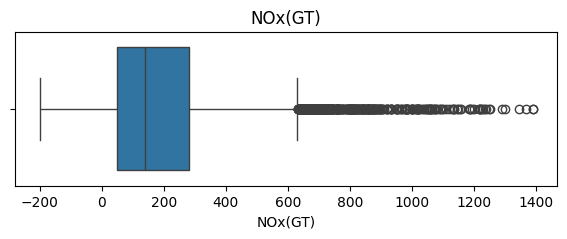

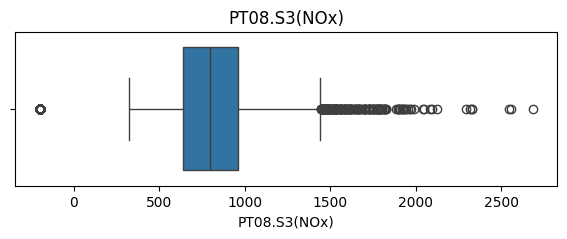

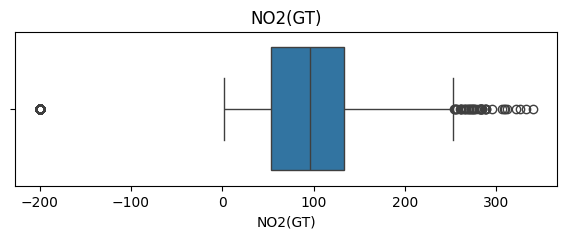

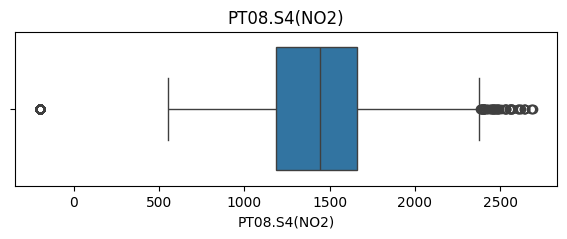

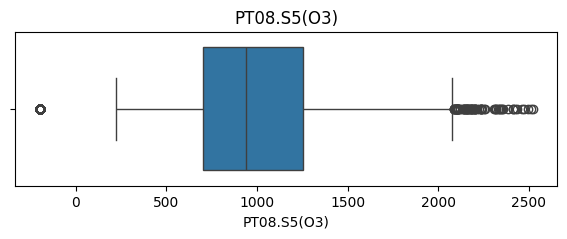

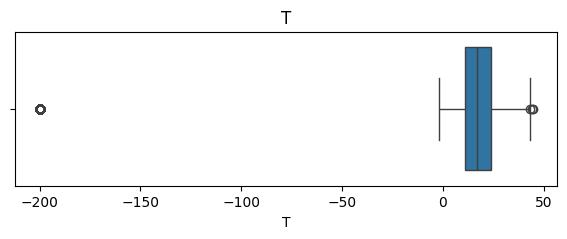

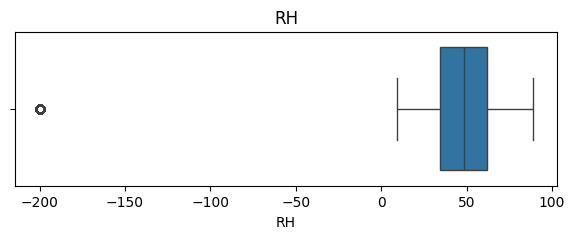

In [14]:
for col in train_data.columns[3:-1]:

    plt.figure(figsize=(7,2))

    sns.boxplot(
        x=train_data[col]
    )

    plt.title(col)

    plt.show()

#Bivariate Analysis

###Feature vs Target Relationship

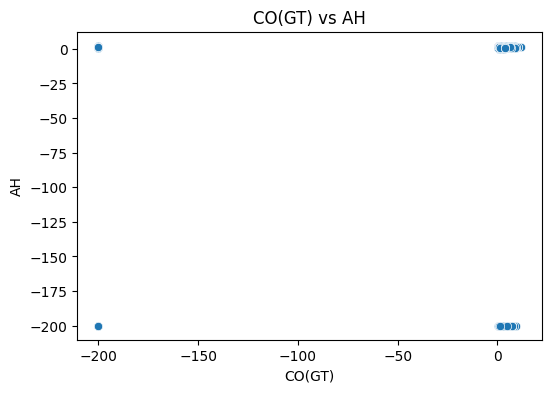

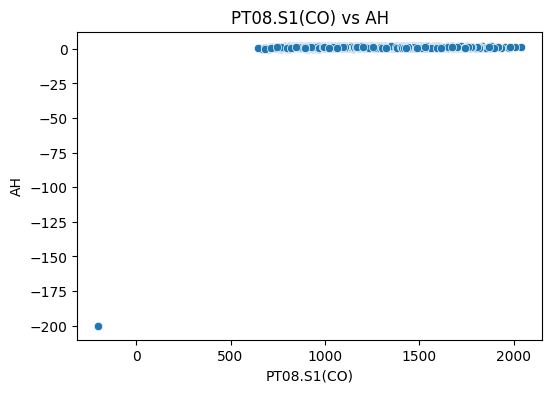

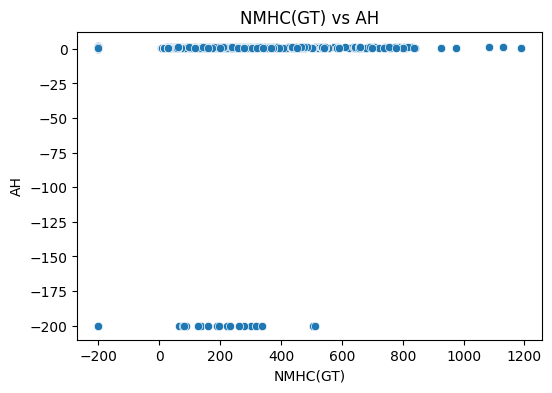

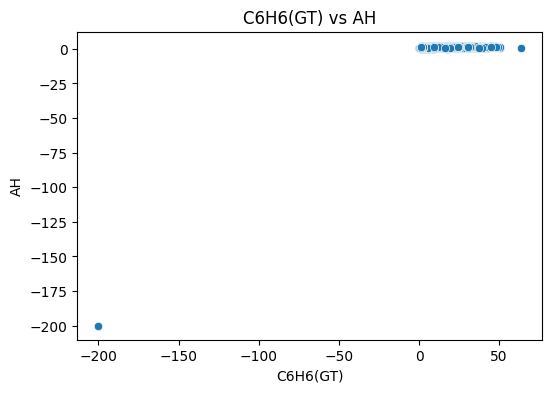

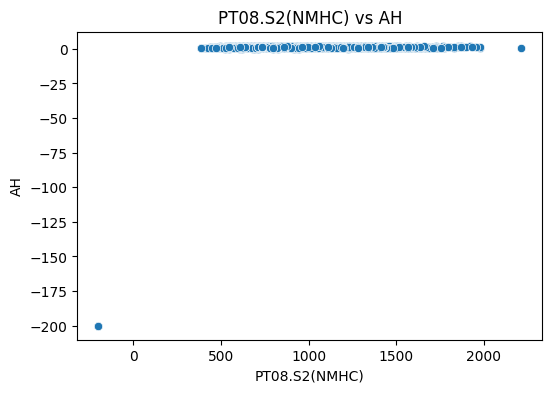

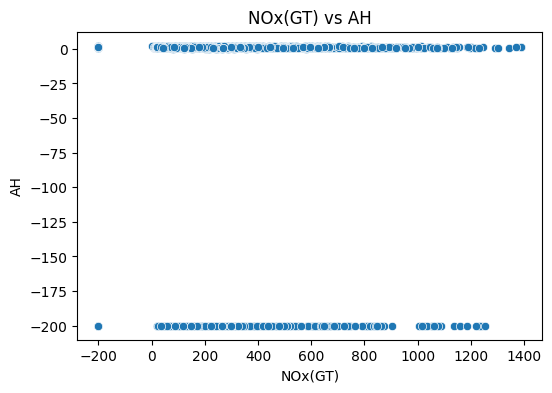

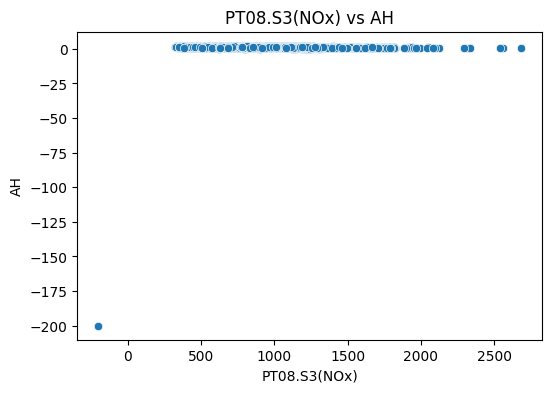

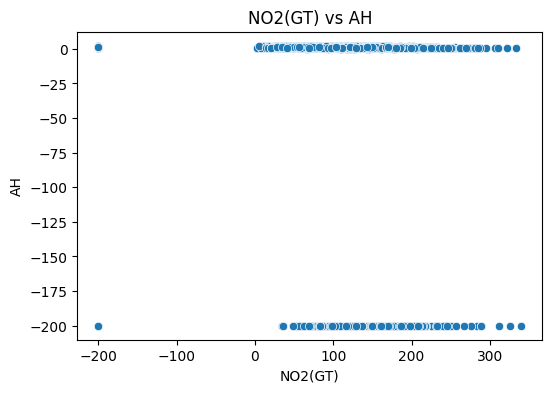

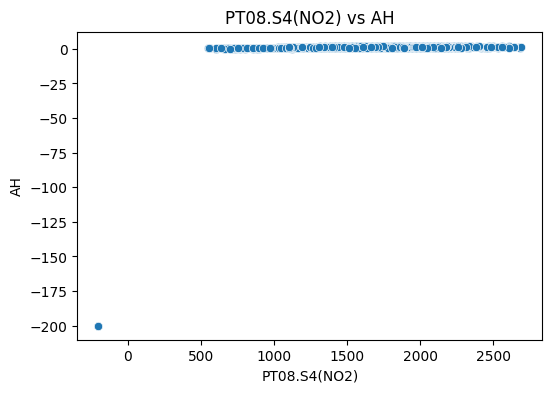

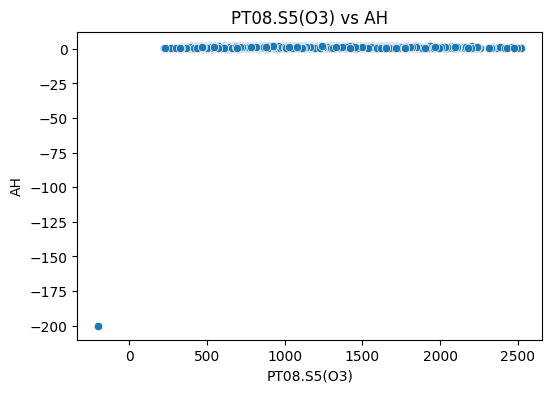

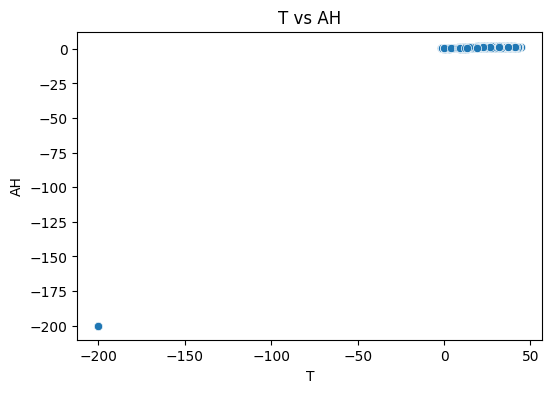

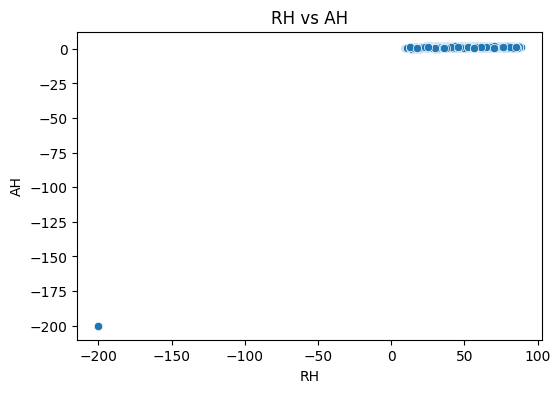

In [15]:
features = train_data.drop(
    ['ID','Date','Time','AH'],
    axis=1
).columns

for col in features:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x=train_data[col],
        y=train_data['AH']
    )

    plt.title(f"{col} vs AH")

    plt.show()

## Correlation Analysis

In [16]:
corr_matrix = train_data.drop(
    ['ID','Date','Time'],
    axis=1
).corr()

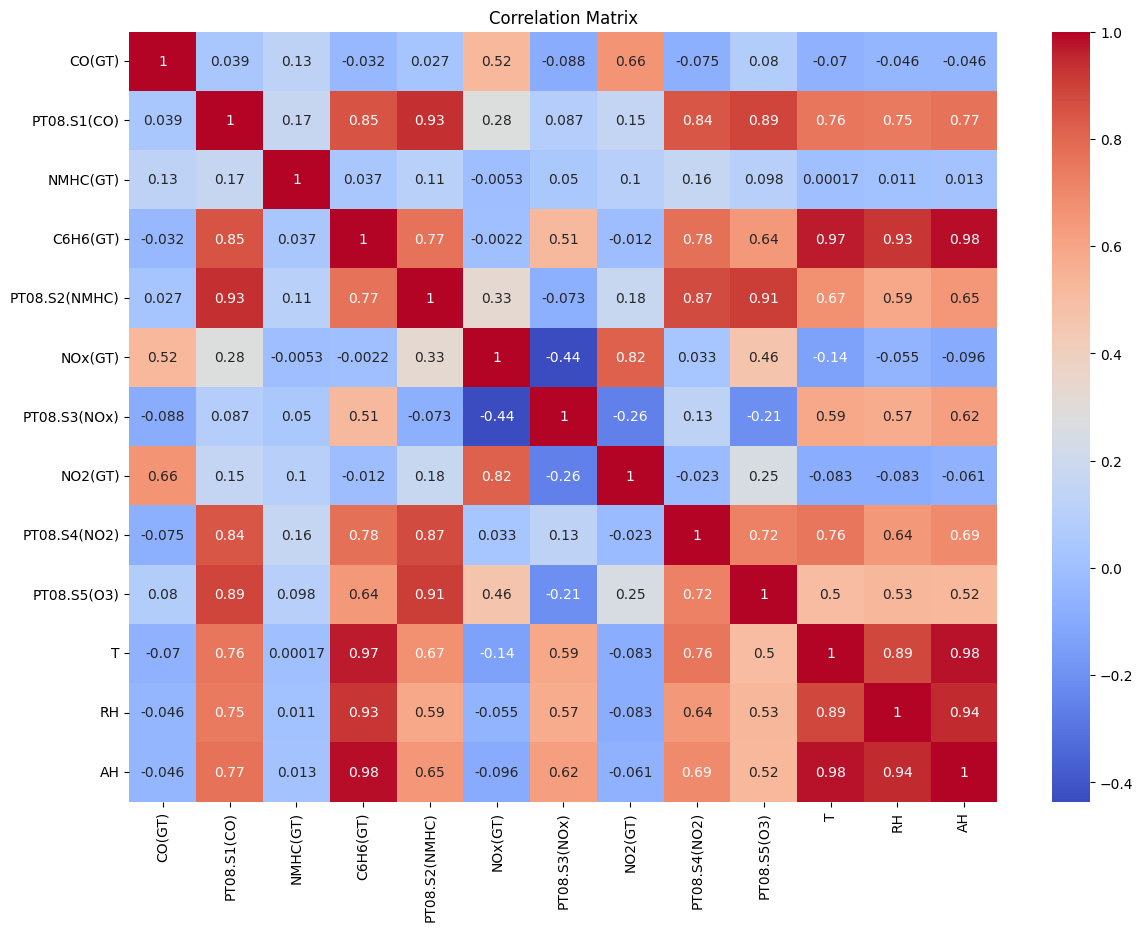

In [17]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

##Features Most Correlated With AH

In [18]:
corr_matrix['AH'].sort_values(
    ascending=False
)

,AH
AH,1.000000
C6H6(GT),0.984715
T,0.981169
RH,0.944283
PT08.S1(CO),0.766202
PT08.S4(NO2),0.693647
PT08.S2(NMHC),0.647451
PT08.S3(NOx),0.620919
PT08.S5(O3),0.520711
NMHC(GT),0.013255


#Feature Engineering & Preprocessing

##Feature Selection

In [19]:
X = train_data.drop(
    ['ID','Date','Time','AH'],
    axis=1
)

y = train_data['AH']

###Feature Scaling

In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

##Model Building

In [21]:
model = LinearRegression()

model.fit(
    X_scaled,
    y
)

LinearRegression()

##Model Evaluation

In [22]:
train_predictions = model.predict(
    X_scaled
)

In [23]:
r2 = r2_score(
    y,
    train_predictions
)

mae = mean_absolute_error(
    y,
    train_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y,
        train_predictions
    )
)

print("R² Score :", r2)
print("MAE :", mae)
print("RMSE :", rmse)

R² Score : 0.9993324429352164
MAE : 0.7438131977372643
RMSE : 1.009007291703184


## Actual vs Predicted Visualization

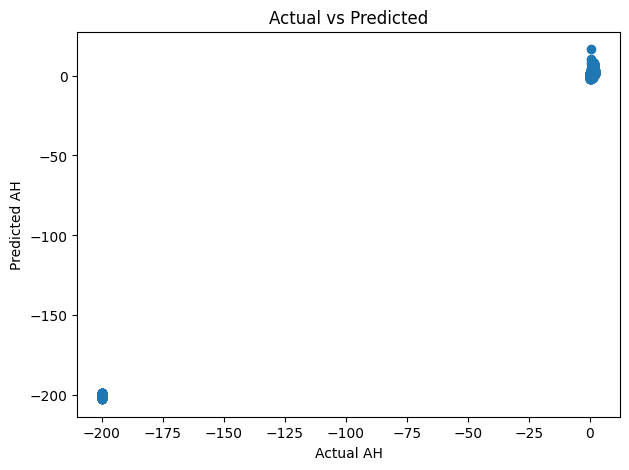

In [24]:
plt.figure(figsize=(7,5))

plt.scatter(
    y,
    train_predictions
)

plt.xlabel("Actual AH")
plt.ylabel("Predicted AH")

plt.title("Actual vs Predicted")

plt.show()

##Residual Analysis

In [25]:
residuals = y - train_predictions

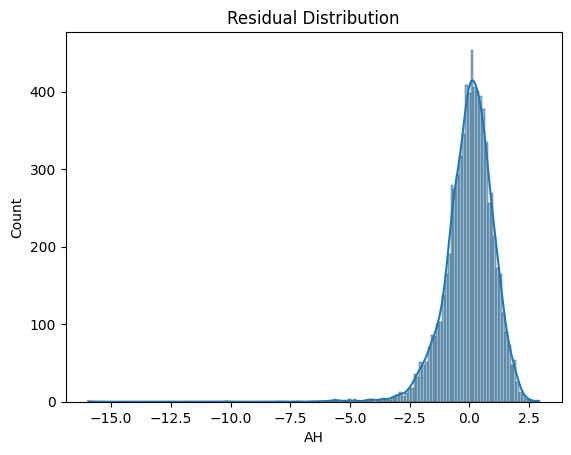

In [26]:
sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")
plt.show()

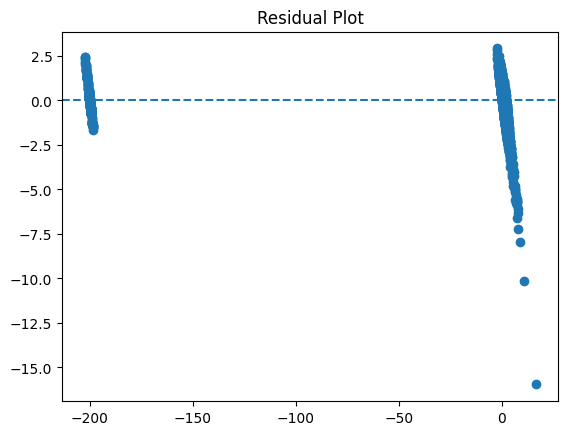

In [27]:
plt.scatter(
    train_predictions,
    residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title("Residual Plot")

plt.show()

##Model Interpretation

In [28]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance_df.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
3,C6H6(GT),32.306219
10,T,9.576369
11,RH,3.723163
7,NO2(GT),0.671678
9,PT08.S5(O3),0.351942
2,NMHC(GT),0.243398
0,CO(GT),-0.006657
1,PT08.S1(CO),-0.205499
6,PT08.S3(NOx),-0.350453
5,NOx(GT),-0.847423


##Feature Importance Visualization

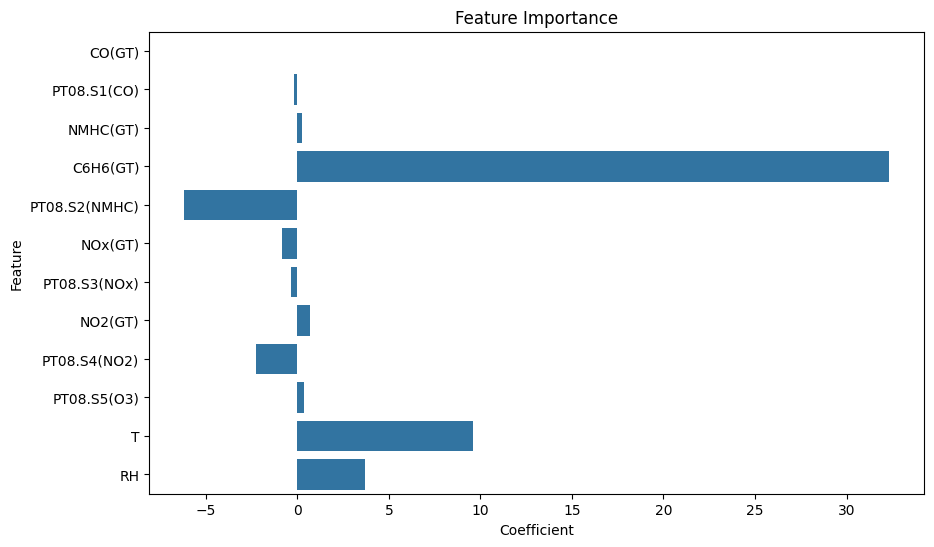

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x='Coefficient',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

##Test Dataset Prediction

In [30]:
X_test = test_data.drop(
    ['ID','Date','Time'],
    axis=1
)

X_test_scaled = scaler.transform(
    X_test
)

In [31]:
predictions = model.predict(
    X_test_scaled
)

In [32]:
submission_df = pd.DataFrame({
    'ID': test_data['ID'],
    'Multiple_AH': predictions
})

submission_df.head()

,ID,Multiple_AH
0,2973,0.489195
1,3396,1.268277
2,4372,1.235128
3,6025,-0.354805
4,7960,0.006996


## Conclusion

Successfully developed a Multiple Linear Regression model for predicting Absolute Humidity.

### Results

- R² Score : 0.9993324429352164
- MAE : 0.7438131977372643
- RMSE : 1.009007291703184

### Future Improvements

- Ridge Regression
- Lasso Regression
- Polynomial Regression
- Random Forest Regression
- XGBoost Regression